In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def analyse(layer_num, feature):
    # --- Config ---

    if layer_num==1:
        csv_path = f"./lang2vec_probing/results/flores_plus-shared-flores_plus/{feature}_probes_shared.csv"  # <-- change this
    else:
        csv_path = f"./lang2vec_probing/results/{layer_num}/flores_plus-shared-flores_plus/{feature}_probes_shared.csv"  # <-- change this
    
    sns.set(style="whitegrid")
    

    # --- Load data ---
    df = pd.read_csv(csv_path)
    display(df.head())

    # --- Aggregate per neuron ---
    neuron_stats = df.groupby(["layer", "neuron_idx"]).agg(
        mean_r2=("r2_score", "mean"),
        max_r2=("r2_score", "max"),
        num_source_langs=("num_source_langs", "first"),
        entropy=("entropy", "first") if "entropy" in df.columns else ("r2_score", "size")
    ).reset_index()

    print("Correlation of sharing (num_source_langs) with mean and max R²:")
    display(neuron_stats[["num_source_langs", "mean_r2", "max_r2"]].corr())

    # --- Per-feature correlation ---
    feature_corrs = df.groupby("feature_name").apply(
        lambda g: g[["num_source_langs", "r2_score"]].corr().iloc[0, 1]
    )
    print("\nTop 20 features most correlated with sharing:")
    display(feature_corrs.sort_values(ascending=False).head(20))

    # --- Layer-wise correlation ---
    layer_corrs = df.groupby("layer").apply(
        lambda g: g[["num_source_langs", "r2_score"]].corr().iloc[0, 1]
    )
    print("\nLayer-wise correlation between num_source_langs and R²:")
    display(layer_corrs)

    # --- Scatter: sharing vs mean R² ---
    plt.figure(figsize=(7, 5))
    sns.scatterplot(data=neuron_stats, x="num_source_langs", y="mean_r2")
    plt.title("Neuron sharing vs mean R²")
    plt.xlabel("Number of source languages")
    plt.ylabel("Mean R²")
    plt.show()

    # --- Boxplot: distribution by sharing level ---
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=neuron_stats, x="num_source_langs", y="mean_r2")
    plt.title("Distribution of mean R² by sharing level")
    plt.xlabel("Number of source languages")
    plt.ylabel("Mean R²")
    plt.show()

    # --- Entropy analysis (if available) ---
    if "entropy" in df.columns:
        neuron_entropy_stats = df.groupby(["layer", "neuron_idx"]).agg(
            mean_r2=("r2_score", "mean"),
            entropy=("entropy", "first")
        ).reset_index()

        print("\nCorrelation between entropy and mean R²:")
        display(neuron_entropy_stats[["entropy", "mean_r2"]].corr())

        plt.figure(figsize=(7, 5))
        sns.scatterplot(data=neuron_entropy_stats, x="entropy", y="mean_r2")
        plt.title("Neuron entropy vs mean R²")
        plt.xlabel("Entropy of neuron sharing")
        plt.ylabel("Mean R²")
        plt.show()

    # --- High R² analysis with proportions ---
    threshold = 0.6  # cutoff for "high R²"

    # High R² subset
    high_r2_df = df[df["r2_score"] >= threshold]

    # Total counts per combo
    total_counts = df.groupby("source_languages").agg(
        total=("r2_score", "size")
    )

    # High counts per combo
    high_counts = high_r2_df.groupby("source_languages").agg(
        high=("r2_score", "size"),
        mean_high_r2=("r2_score", "mean"),
        max_high_r2=("r2_score", "max")
    )

    # Merge
    combo_stats = total_counts.join(high_counts, how="left").fillna(0)
    combo_stats["proportion_high"] = combo_stats["high"] / combo_stats["total"]

    # Sort
    combo_stats = combo_stats.sort_values("proportion_high", ascending=False).reset_index()

    print(f"Top language combinations by proportion of high-R² (≥ {threshold}) neurons:")
    display(combo_stats.head(20))

    # --- Plot top combos by proportion ---
    plt.figure(figsize=(10, 6))
    sns.barplot(data=combo_stats.head(15), y="source_languages", x="proportion_high", palette="mako")
    plt.title(f"Proportion of high-R² (≥ {threshold}) neuron-feature pairs per language combo")
    plt.xlabel("Proportion of high-R²")
    plt.ylabel("Language combination")
    plt.tight_layout()
    plt.show()

    # --- Per-language high R² analysis ---
    threshold = 0.6  # cutoff for "high R²"

    # Expand source_languages into sets for easier membership queries
    df["lang_set"] = df["source_languages"].apply(lambda s: set(s.split(",")))

    # Total counts per language: how many (neuron,feature) pairs involve each language
    from collections import Counter

    all_lang_counts = Counter()
    high_lang_counts = Counter()

    for _, row in df.iterrows():
        for lang in row["lang_set"]:
            all_lang_counts[lang] += 1
            if row["r2_score"] >= threshold:
                high_lang_counts[lang] += 1

    # Build DataFrame
    lang_stats = pd.DataFrame([
        {
            "language": lang,
            "total_pairs": all_lang_counts[lang],
            "high_pairs": high_lang_counts[lang],
            "proportion_high": high_lang_counts[lang] / all_lang_counts[lang] if all_lang_counts[lang] > 0 else 0
        }
        for lang in sorted(all_lang_counts.keys())
    ])

    # Sort by proportion or absolute count
    lang_stats = lang_stats.sort_values("proportion_high", ascending=False).reset_index(drop=True)

    print(f"Per-language high R² analysis (threshold = {threshold}):")
    display(lang_stats)

    # --- Plot: proportion of high R² per language ---
    plt.figure(figsize=(10, 6))
    sns.barplot(data=lang_stats, x="language", y="proportion_high", palette="crest")
    plt.title(f"Proportion of high-R² (≥ {threshold}) neuron-feature pairs per language")
    plt.ylabel("Proportion of high-R²")
    plt.xlabel("Language")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # --- Plot: absolute number of high R² pairs per language ---
    plt.figure(figsize=(10, 6))
    sns.barplot(data=lang_stats.sort_values("high_pairs", ascending=False),
                x="language", y="high_pairs", palette="viridis")
    plt.title(f"Number of high-R² (≥ {threshold}) neuron-feature pairs per language")
    plt.ylabel("High-R² pairs")
    plt.xlabel("Language")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


    # --- Conditional combo analysis ---
    target_lang = "hi"   # change this to the language you want to study
    threshold = 0.6      # optional, for high R² filtering

    # Filter to neurons that involve target_lang
    df_target = df[df["source_languages"].str.contains(target_lang)]

    # Create a column with "other languages" = combo minus the target_lang
    df_target["other_langs"] = df_target["source_languages"].apply(
        lambda s: ",".join(sorted(set(s.split(",")) - {target_lang}))
    )

    print(f"Neurons involving {target_lang}: {len(df_target)} rows")

    # --- Aggregate statistics per "other langs" combination ---
    combo_stats = df_target.groupby("other_langs").agg(
        count=("r2_score", "size"),
        mean_r2=("r2_score", "mean"),
        max_r2=("r2_score", "max"),
        high_count=("r2_score", lambda x: (x >= threshold).sum()),
        prop_high=("r2_score", lambda x: (x >= threshold).mean())
    ).reset_index().sort_values("max_r2", ascending=False)

    print(f"\nTop combos shared with {target_lang} (sorted by max R²):")
    display(combo_stats.head(20))

    # --- Plot: mean R² by combo (top N) ---
    topN = 15
    plt.figure(figsize=(10, 6))
    sns.barplot(data=combo_stats.head(topN), y="other_langs", x="max_r2", palette="viridis")
    plt.title(f"Max R² for neurons involving {target_lang} by co-sharing languages")
    plt.xlabel("Max R²")
    plt.ylabel(f"Other languages with {target_lang}")
    plt.tight_layout()
    plt.show()

    # --- Plot: proportion high R² by combo (top N by count) ---
    plt.figure(figsize=(10, 6))
    sns.barplot(data=combo_stats.sort_values("count", ascending=False).head(topN),
                y="other_langs", x="prop_high", palette="mako")
    plt.title(f"Proportion of high-R² (≥ {threshold}) neurons with {target_lang}")
    plt.xlabel("Proportion high R²")
    plt.ylabel(f"Other languages with {target_lang}")
    plt.tight_layout()
    plt.show()



,layer,neuron_idx,source_languages,num_source_langs,feature_set,feature_name,feature_idx,r2_score
0,1,2,"bn,de,en,es,fr,hi,it,ja,ko,pt,ru,tr,ur,zh",14,syntax_wals,syntax_wals_0,0,0.127189
1,1,2,"bn,de,en,es,fr,hi,it,ja,ko,pt,ru,tr,ur,zh",14,syntax_wals,syntax_wals_1,1,0.207412
2,1,2,"bn,de,en,es,fr,hi,it,ja,ko,pt,ru,tr,ur,zh",14,syntax_wals,syntax_wals_7,7,0.002203
3,1,2,"bn,de,en,es,fr,hi,it,ja,ko,pt,ru,tr,ur,zh",14,syntax_wals,syntax_wals_8,8,0.127189
4,1,2,"bn,de,en,es,fr,hi,it,ja,ko,pt,ru,tr,ur,zh",14,syntax_wals,syntax_wals_9,9,0.207412


Correlation of sharing (num_source_langs) with mean and max R²:


,num_source_langs,mean_r2,max_r2
num_source_langs,1.000000,-0.032546,-0.030666
mean_r2,-0.032546,1.000000,0.431447
max_r2,-0.030666,0.431447,1.000000



Top 20 features most correlated with sharing:


/tmp/ipykernel_1330463/2073234458.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  feature_corrs = df.groupby("feature_name").apply(


feature_name
syntax_wals_44    0.229320
syntax_wals_55    0.169404
syntax_wals_16    0.158823
syntax_wals_14    0.158823
syntax_wals_27    0.158823
syntax_wals_58    0.158823
syntax_wals_43    0.135805
syntax_wals_0     0.120455
syntax_wals_8     0.120455
syntax_wals_9     0.105860
syntax_wals_1     0.105860
syntax_wals_76    0.095855
syntax_wals_31    0.082827
syntax_wals_71    0.077528
syntax_wals_17    0.065417
syntax_wals_48    0.060154
syntax_wals_37    0.030369
syntax_wals_79    0.019396
syntax_wals_62    0.014689
syntax_wals_39    0.009779
dtype: float64


Layer-wise correlation between num_source_langs and R²:


/tmp/ipykernel_1330463/2073234458.py:39: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  layer_corrs = df.groupby("layer").apply(


layer
1   -0.006921
dtype: float64

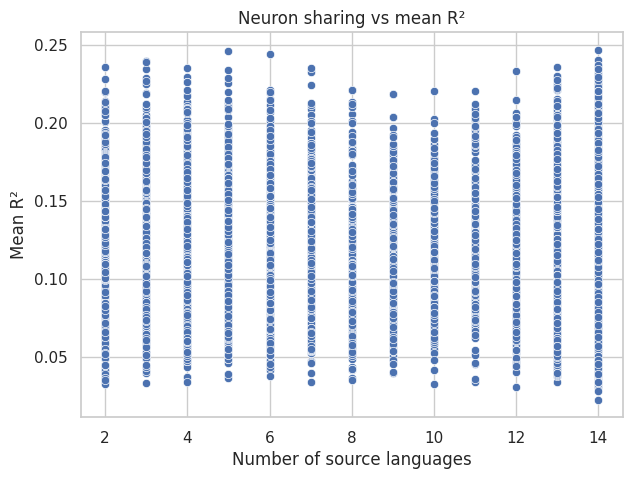

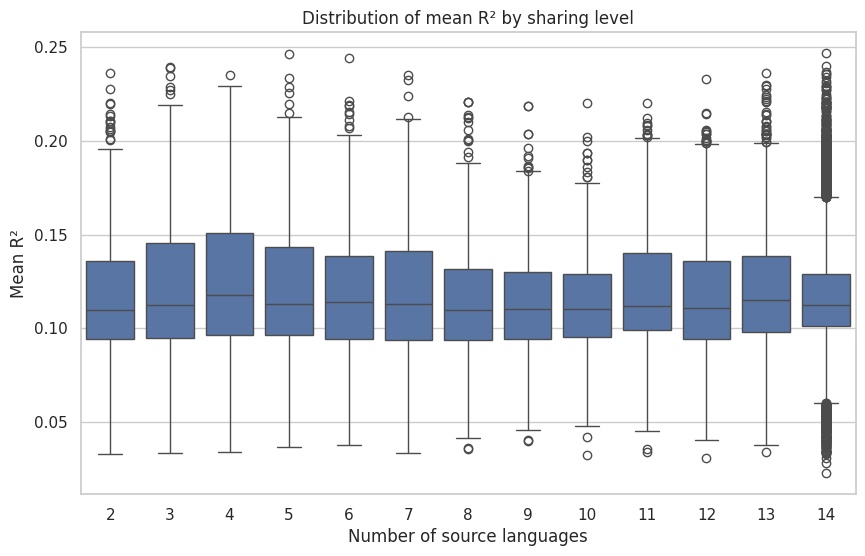

Top language combinations by proportion of high-R² (≥ 0.6) neurons:


,source_languages,total,high,mean_high_r2,max_high_r2,proportion_high
0,"de,es,fr,hi,it,pt,ur",68,8.0,0.674444,0.693493,0.117647
1,"bn,es,hi,it,ko,pt,ru,tr,ur",68,7.0,0.658396,0.725702,0.102941
2,"bn,en,es,ru",68,7.0,0.658752,0.739142,0.102941
3,"de,en,es,fr,it,pt,tr,ur",68,6.0,0.701010,0.761165,0.088235
4,"en,es,ur",68,6.0,0.665003,0.761618,0.088235
5,"de,en,es,fr,hi,it,ja,ko,pt,tr",136,11.0,0.681253,0.789261,0.080882
6,"bn,de,es,fr,hi",68,5.0,0.712868,0.725261,0.073529
7,"de,en,hi",68,5.0,0.789340,0.828926,0.073529
8,"bn,en,es,it,pt",68,5.0,0.660373,0.686357,0.073529
9,"bn,de,fr,hi,it,ja,ru,ur",68,5.0,0.666238,0.778132,0.073529


/tmp/ipykernel_1330463/2073234458.py:108: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=combo_stats.head(15), y="source_languages", x="proportion_high", palette="mako")


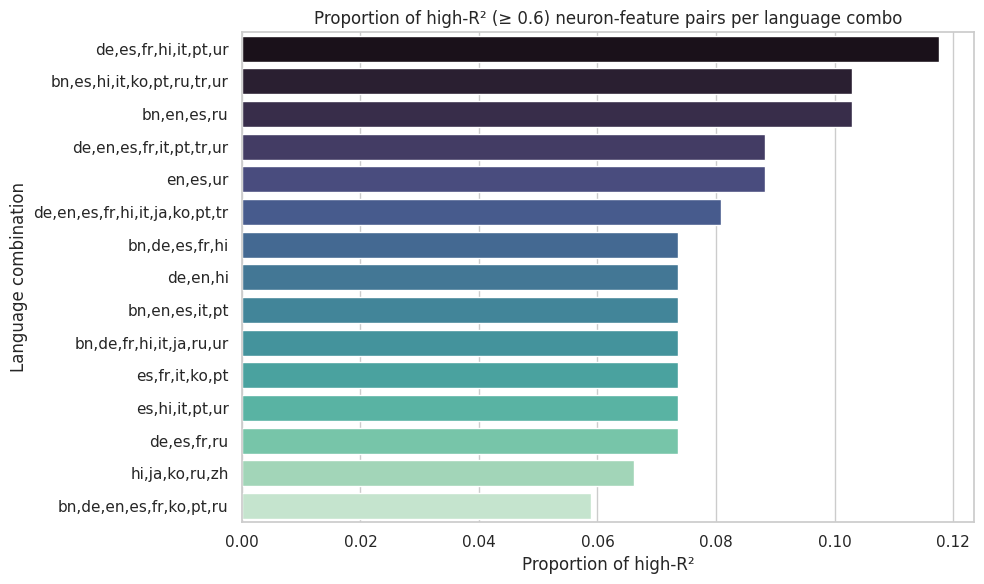

Per-language high R² analysis (threshold = 0.6):


,language,total_pairs,high_pairs,proportion_high
0,ur,667828,10603,0.015877
1,bn,736236,11631,0.015798
2,es,962880,14964,0.015541
3,fr,960364,14921,0.015537
4,hi,796756,12316,0.015458
5,tr,754324,11656,0.015452
6,ja,779824,12019,0.015412
7,it,922624,14215,0.015407
8,ko,761804,11737,0.015407
9,pt,907528,13960,0.015382


/tmp/ipykernel_1330463/2073234458.py:152: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=lang_stats, x="language", y="proportion_high", palette="crest")


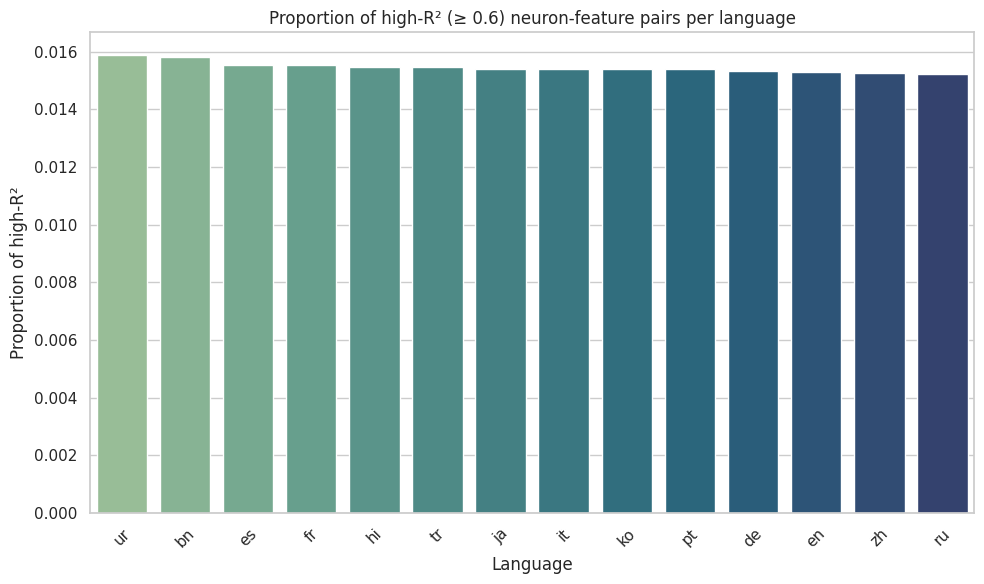

/tmp/ipykernel_1330463/2073234458.py:162: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=lang_stats.sort_values("high_pairs", ascending=False),


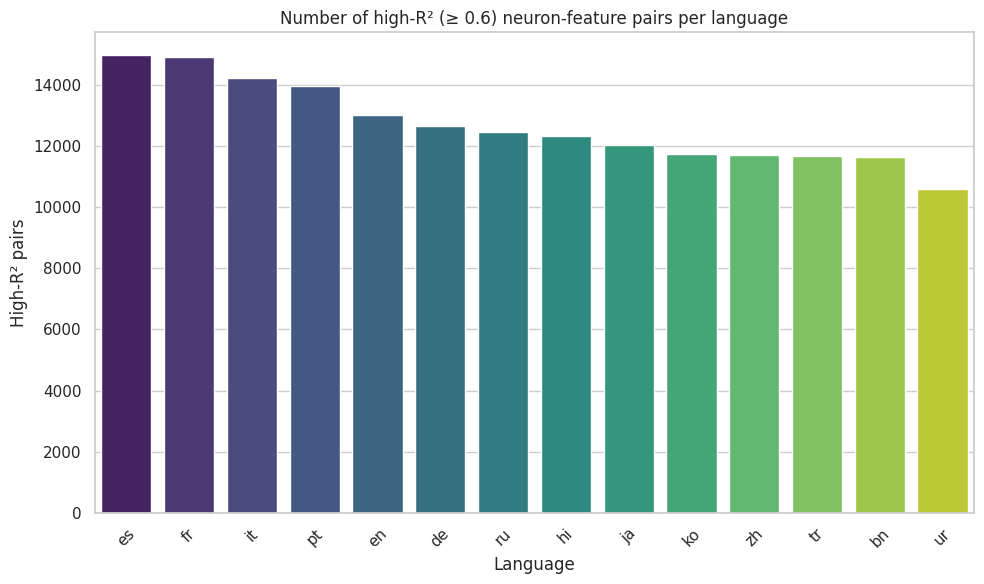

/tmp/ipykernel_1330463/2073234458.py:180: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_target["other_langs"] = df_target["source_languages"].apply(


Neurons involving hi: 796756 rows

Top combos shared with hi (sorted by max R²):


,other_langs,count,mean_r2,max_r2,high_count,prop_high
7,"bn,de,en,es,fr,it,ja,ko,pt,ru,tr,zh",65824,0.121287,0.999730,953,0.014478
464,"de,es,fr",68,0.106431,0.999310,4,0.058824
6,"bn,de,en,es,fr,it,ja,ko,pt,ru,tr,ur,zh",577524,0.115972,0.999208,9121,0.015793
581,"en,es,fr,it,pt,tr",136,0.152806,0.999061,7,0.051471
457,"de,en,ja,ru,tr",68,0.106168,0.998857,4,0.058824
352,"de,en,es,fr,it,ja,ko,pt,ru,zh",1768,0.110116,0.997747,15,0.008484
25,"bn,de,en,es,fr,it,ja,pt,ru,zh",476,0.143966,0.997193,9,0.018908
333,"bn,ko,ru",68,0.104659,0.997107,4,0.058824
662,"es,fr,it,pt,ru",544,0.109151,0.994137,16,0.029412
5,"bn,de,en,es,fr,it,ja,ko,pt,ru,tr,ur",2244,0.117436,0.993710,32,0.014260


/tmp/ipykernel_1330463/2073234458.py:201: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=combo_stats.head(topN), y="other_langs", x="max_r2", palette="viridis")


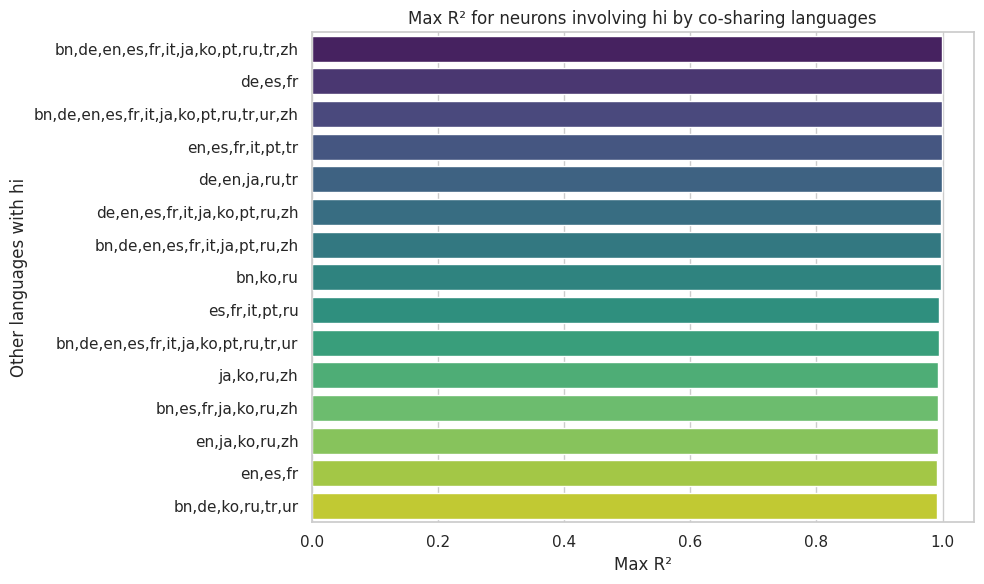

/tmp/ipykernel_1330463/2073234458.py:210: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=combo_stats.sort_values("count", ascending=False).head(topN),


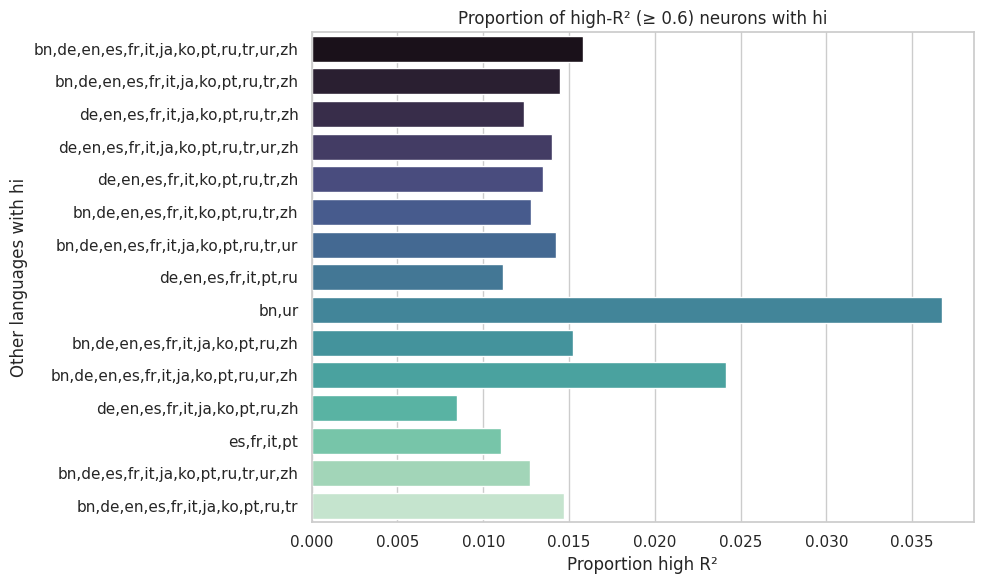

In [33]:
analyse(1, "syntax_wals")

,layer,neuron_idx,source_languages,num_source_langs,feature_set,feature_name,feature_idx,r2_score
0,8,32,"bn,de,en,es,fr,hi,it,ja,ko,pt,ru,tr,zh",13,syntax_wals,syntax_wals_0,0,0.059099
1,8,32,"bn,de,en,es,fr,hi,it,ja,ko,pt,ru,tr,zh",13,syntax_wals,syntax_wals_1,1,0.011984
2,8,32,"bn,de,en,es,fr,hi,it,ja,ko,pt,ru,tr,zh",13,syntax_wals,syntax_wals_7,7,0.030445
3,8,32,"bn,de,en,es,fr,hi,it,ja,ko,pt,ru,tr,zh",13,syntax_wals,syntax_wals_8,8,0.059099
4,8,32,"bn,de,en,es,fr,hi,it,ja,ko,pt,ru,tr,zh",13,syntax_wals,syntax_wals_9,9,0.011984


Correlation of sharing (num_source_langs) with mean and max R²:


,num_source_langs,mean_r2,max_r2
num_source_langs,1.000000,-0.000238,0.012771
mean_r2,-0.000238,1.000000,0.475604
max_r2,0.012771,0.475604,1.000000



Top 20 features most correlated with sharing:


/tmp/ipykernel_1330463/3004055008.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  feature_corrs = df.groupby("feature_name").apply(


feature_name
syntax_wals_48    0.031915
syntax_wals_39    0.030123
syntax_wals_16    0.029522
syntax_wals_14    0.029522
syntax_wals_27    0.029522
syntax_wals_58    0.029522
syntax_wals_31    0.026236
syntax_wals_55    0.022467
syntax_wals_79    0.022460
syntax_wals_65    0.017829
syntax_wals_44    0.013811
syntax_wals_71    0.013003
syntax_wals_62    0.011915
syntax_wals_66    0.009997
syntax_wals_35    0.008343
syntax_wals_15    0.006135
syntax_wals_43    0.006066
syntax_wals_70    0.005904
syntax_wals_75    0.005792
syntax_wals_92    0.005732
dtype: float64


Layer-wise correlation between num_source_langs and R²:


/tmp/ipykernel_1330463/3004055008.py:39: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  layer_corrs = df.groupby("layer").apply(


layer
8   -0.000057
dtype: float64

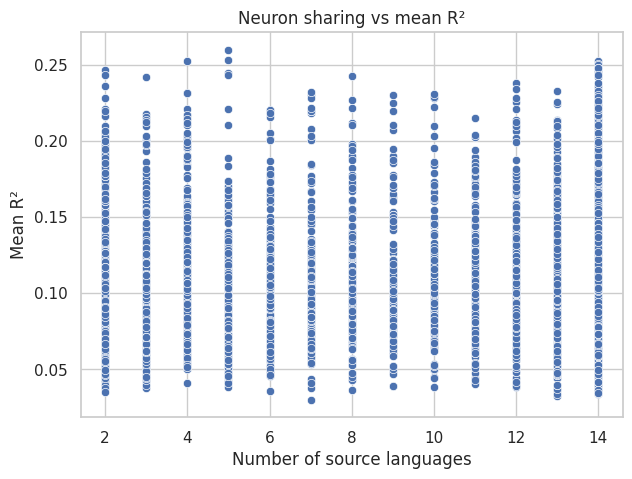

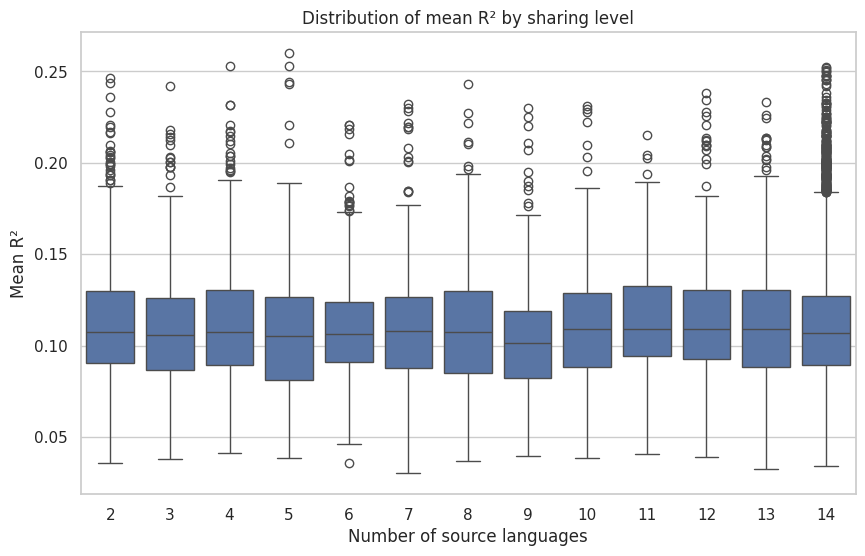

Top language combinations by proportion of high-R² (≥ 0.6) neurons:


,source_languages,total,high,mean_high_r2,max_high_r2,proportion_high
0,"en,es,hi,it,ja,pt,ru,ur,zh",68,12.0,0.720342,0.860602,0.176471
1,"en,ja,ur,zh",68,10.0,0.707356,0.794738,0.147059
2,"bn,de,fr,it,ja,ru,ur",68,10.0,0.746454,0.856798,0.147059
3,"bn,de,es,fr,hi,it,ja,pt,ru,tr",68,9.0,0.673423,0.734465,0.132353
4,"en,fr,hi,ja",68,8.0,0.703803,0.793659,0.117647
5,"en,es,fr,hi,it,ja,ko,pt,ru,tr,ur,zh",68,8.0,0.757863,0.869264,0.117647
6,"en,ja,ko,zh",68,7.0,0.707177,0.743082,0.102941
7,"bn,es,fr,hi,it,pt,ur",68,7.0,0.757572,0.811490,0.102941
8,"hi,ja,ur",68,7.0,0.700889,0.835994,0.102941
9,"hi,ja,ko,ur",136,13.0,0.741741,0.915535,0.095588


/tmp/ipykernel_1330463/3004055008.py:108: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=combo_stats.head(15), y="source_languages", x="proportion_high", palette="mako")


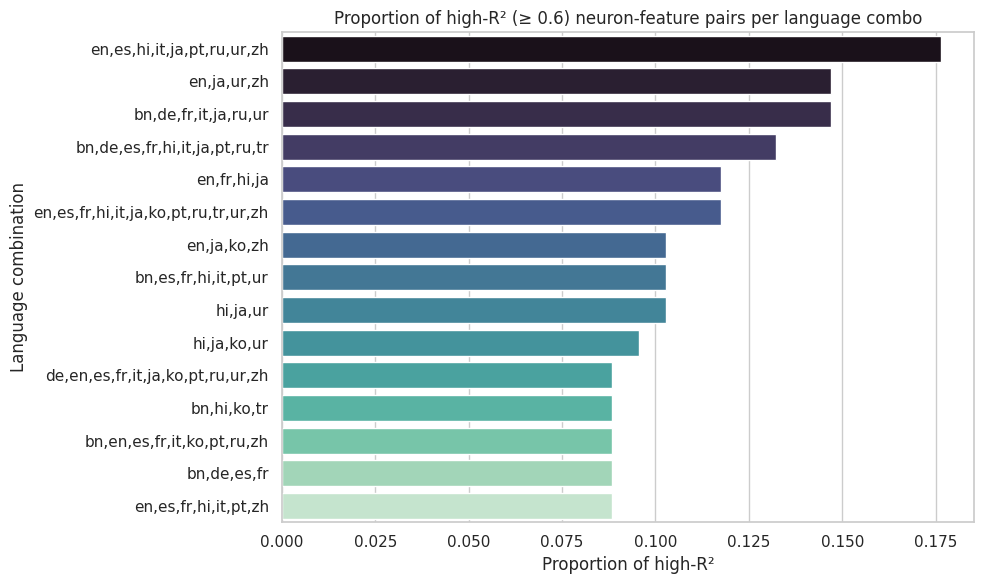

Per-language high R² analysis (threshold = 0.6):


,language,total_pairs,high_pairs,proportion_high
0,ur,283084,6461,0.022824
1,ja,333132,7375,0.022138
2,bn,291788,6454,0.022119
3,hi,344148,7579,0.022023
4,zh,321912,7081,0.021997
5,ko,320960,7005,0.021825
6,tr,309740,6753,0.021802
7,de,345712,7522,0.021758
8,ru,356388,7750,0.021746
9,en,366316,7932,0.021653


/tmp/ipykernel_1330463/3004055008.py:152: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=lang_stats, x="language", y="proportion_high", palette="crest")


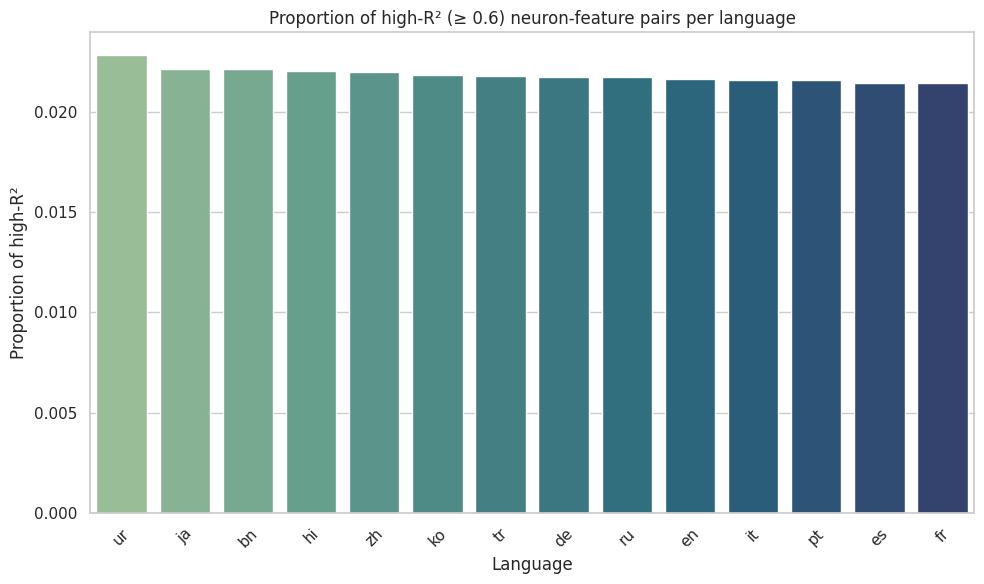

/tmp/ipykernel_1330463/3004055008.py:162: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=lang_stats.sort_values("high_pairs", ascending=False),


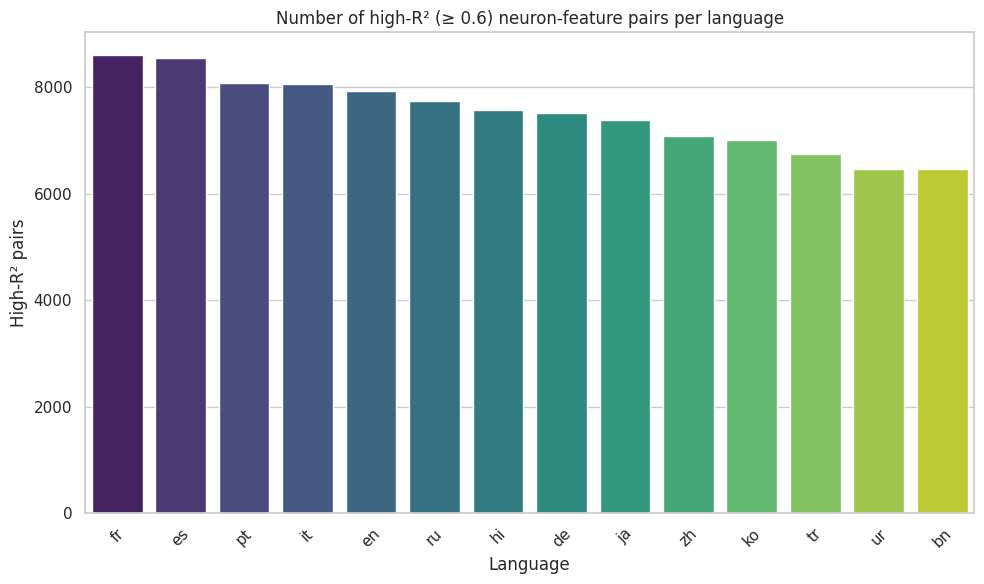

In [25]:
analyse(8, "syntax_wals")

,layer,neuron_idx,source_languages,num_source_langs,feature_set,feature_name,feature_idx,r2_score
0,1,2,"bn,de,en,es,fr,hi,it,ja,ko,pt,ru,tr,ur,zh",14,phonology_ethnologue,phonology_ethnologue_21,21,0.008160
1,1,2,"bn,de,en,es,fr,hi,it,ja,ko,pt,ru,tr,ur,zh",14,phonology_ethnologue,phonology_ethnologue_22,22,0.018529
2,1,2,"bn,de,en,es,fr,hi,it,ja,ko,pt,ru,tr,ur,zh",14,phonology_ethnologue,phonology_ethnologue_25,25,0.008160
3,1,2,"bn,de,en,es,fr,hi,it,ja,ko,pt,ru,tr,ur,zh",14,phonology_ethnologue,phonology_ethnologue_26,26,0.001873
4,1,15,"en,hi,ko,ru,zh",5,phonology_ethnologue,phonology_ethnologue_21,21,0.068053


Correlation of sharing (num_source_langs) with mean and max R²:


,num_source_langs,mean_r2,max_r2
num_source_langs,1.000000,-0.061236,0.054374
mean_r2,-0.061236,1.000000,0.737981
max_r2,0.054374,0.737981,1.000000



Top 20 features most correlated with sharing:


/tmp/ipykernel_1330463/3004055008.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  feature_corrs = df.groupby("feature_name").apply(


feature_name
phonology_ethnologue_22    0.102067
phonology_ethnologue_26   -0.029818
phonology_ethnologue_21   -0.127573
phonology_ethnologue_25   -0.127573
dtype: float64


Layer-wise correlation between num_source_langs and R²:


/tmp/ipykernel_1330463/3004055008.py:39: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  layer_corrs = df.groupby("layer").apply(


layer
1   -0.029412
dtype: float64

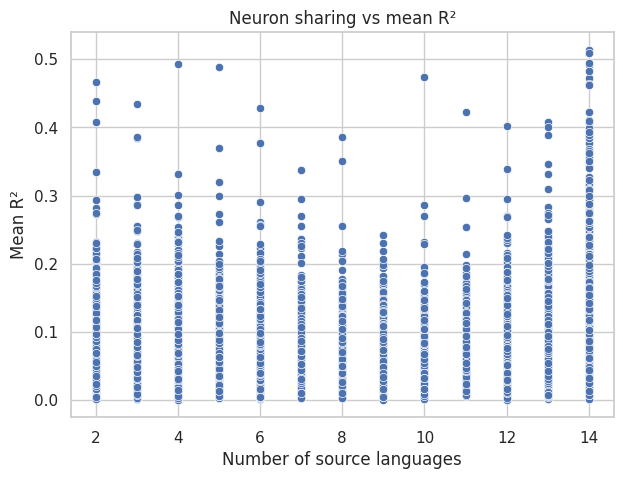

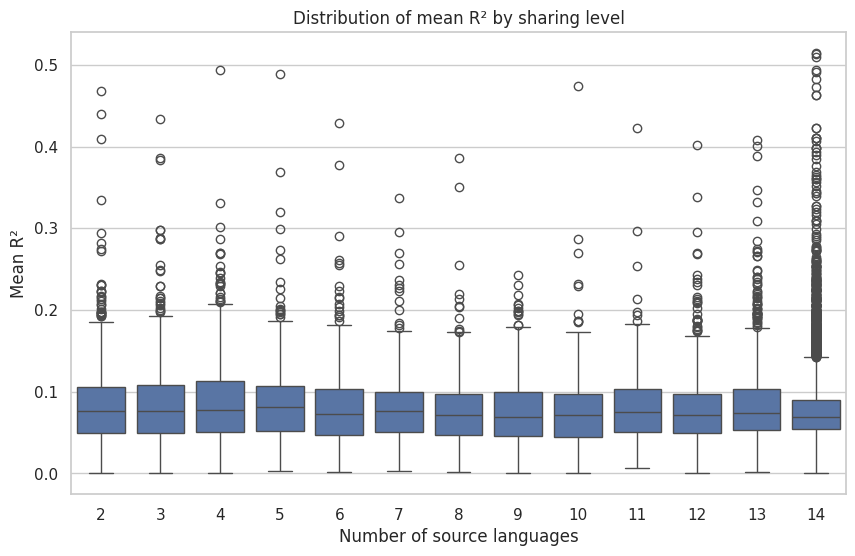

Top language combinations by proportion of high-R² (≥ 0.6) neurons:


,source_languages,total,high,mean_high_r2,max_high_r2,proportion_high
0,"ja,ru,ur",4,2.0,0.697969,0.697969,0.500000
1,"en,fr,ja,ko,ru,zh",4,2.0,0.698468,0.698468,0.500000
2,"hi,ja,ru,ur,zh",4,2.0,0.807551,0.807551,0.500000
3,"de,en,es,fr,ja,pt,ru",4,1.0,0.689100,0.689100,0.250000
4,"en,es,fr,hi,it,ja,ko,pt,ru,tr",8,2.0,0.762795,0.762795,0.250000
5,"de,ur,zh",4,1.0,0.648990,0.648990,0.250000
6,"bn,hi,ja,pt,ru,ur",4,1.0,0.607266,0.607266,0.250000
7,"de,en,es,fr,it,ja,pt,tr",8,2.0,0.616307,0.616307,0.250000
8,"en,ja,ko,ru,tr,zh",12,2.0,0.635395,0.635395,0.166667
9,"fr,ja,ur",12,2.0,0.639716,0.639716,0.166667


/tmp/ipykernel_1330463/3004055008.py:108: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=combo_stats.head(15), y="source_languages", x="proportion_high", palette="mako")


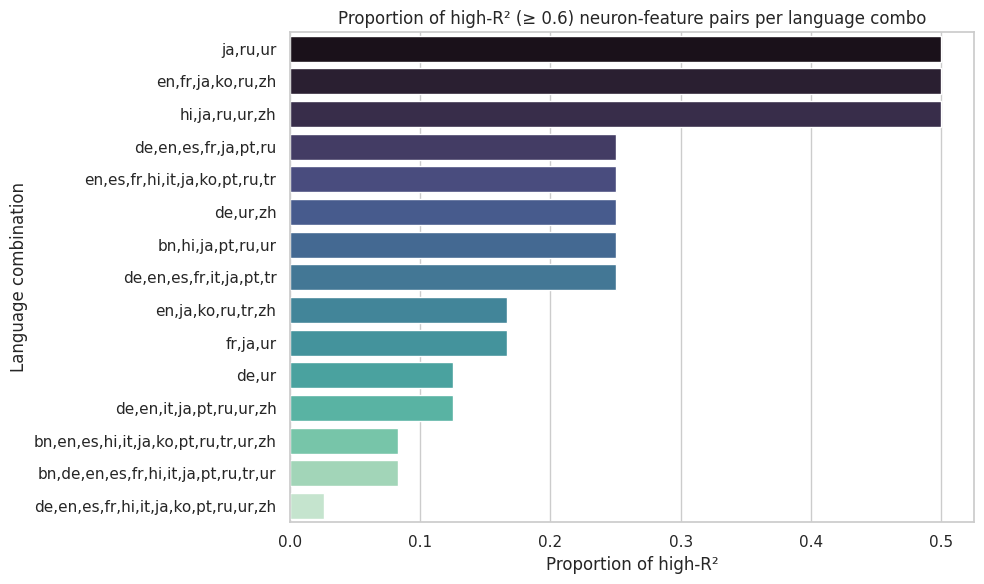

Per-language high R² analysis (threshold = 0.6):


,language,total_pairs,high_pairs,proportion_high
0,ja,45872,80,0.001744
1,ur,39284,65,0.001655
2,ru,48052,77,0.001602
3,zh,45004,69,0.001533
4,ko,44812,68,0.001517
5,tr,44372,66,0.001487
6,en,50028,74,0.001479
7,hi,46868,69,0.001472
8,de,48472,70,0.001444
9,fr,56492,79,0.001398


/tmp/ipykernel_1330463/3004055008.py:152: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=lang_stats, x="language", y="proportion_high", palette="crest")


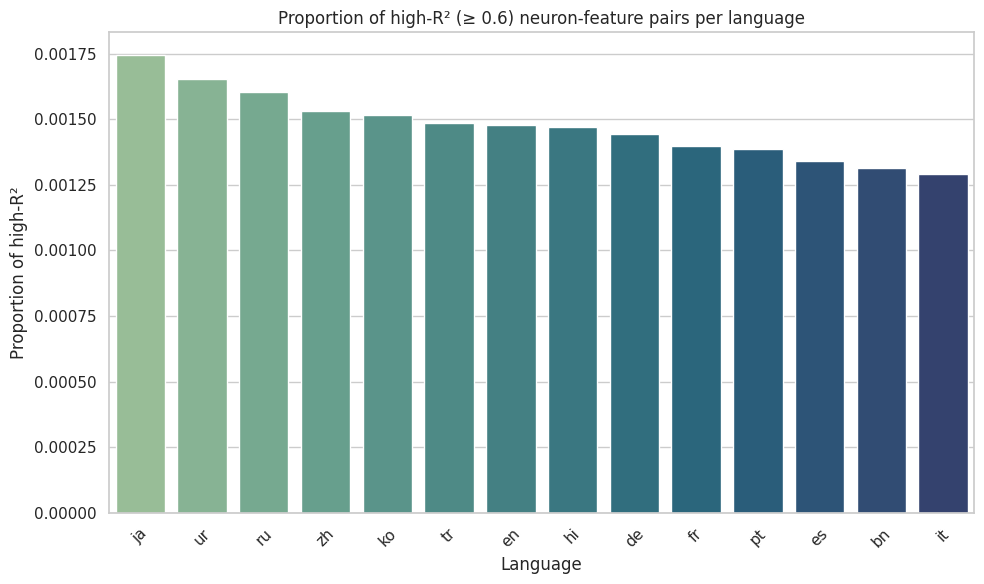

/tmp/ipykernel_1330463/3004055008.py:162: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=lang_stats.sort_values("high_pairs", ascending=False),


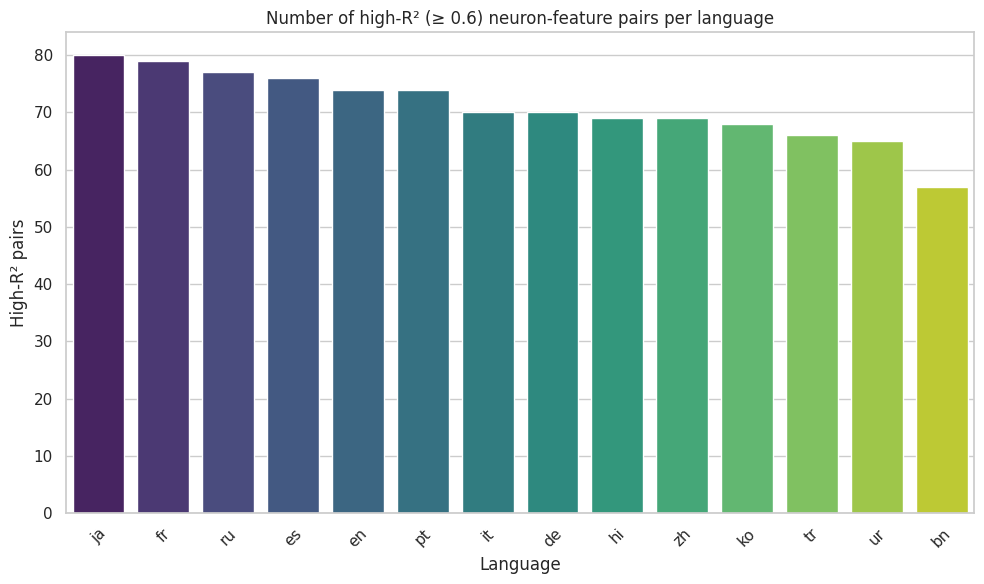

In [26]:
analyse(1, "phonology_ethnologue")

,layer,neuron_idx,source_languages,num_source_langs,feature_set,feature_name,feature_idx,r2_score
0,1,2,"bn,de,en,es,fr,hi,it,ja,ko,pt,ru,tr,ur,zh",14,inventory_phoible_ra,inventory_phoible_ra_6,6,0.002242
1,1,2,"bn,de,en,es,fr,hi,it,ja,ko,pt,ru,tr,ur,zh",14,inventory_phoible_ra,inventory_phoible_ra_11,11,0.000597
2,1,2,"bn,de,en,es,fr,hi,it,ja,ko,pt,ru,tr,ur,zh",14,inventory_phoible_ra,inventory_phoible_ra_12,12,0.002242
3,1,2,"bn,de,en,es,fr,hi,it,ja,ko,pt,ru,tr,ur,zh",14,inventory_phoible_ra,inventory_phoible_ra_19,19,0.000597
4,1,2,"bn,de,en,es,fr,hi,it,ja,ko,pt,ru,tr,ur,zh",14,inventory_phoible_ra,inventory_phoible_ra_27,27,0.000597


Correlation of sharing (num_source_langs) with mean and max R²:


,num_source_langs,mean_r2,max_r2
num_source_langs,1.000000,-0.078053,-0.066404
mean_r2,-0.078053,1.000000,0.968923
max_r2,-0.066404,0.968923,1.000000



Top 20 features most correlated with sharing:


/tmp/ipykernel_1330463/3004055008.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  feature_corrs = df.groupby("feature_name").apply(


feature_name
inventory_phoible_ra_29     0.032497
inventory_phoible_ra_82     0.032497
inventory_phoible_ra_81     0.032497
inventory_phoible_ra_70    -0.038407
inventory_phoible_ra_112   -0.038407
inventory_phoible_ra_58    -0.038407
inventory_phoible_ra_140   -0.038407
inventory_phoible_ra_142   -0.038407
inventory_phoible_ra_12    -0.038407
inventory_phoible_ra_6     -0.038407
inventory_phoible_ra_144   -0.108133
inventory_phoible_ra_11    -0.108133
inventory_phoible_ra_41    -0.108133
inventory_phoible_ra_91    -0.108133
inventory_phoible_ra_19    -0.108133
inventory_phoible_ra_30    -0.108133
inventory_phoible_ra_133   -0.108134
inventory_phoible_ra_139   -0.108134
inventory_phoible_ra_27    -0.108134
inventory_phoible_ra_39    -0.108134
dtype: float64


Layer-wise correlation between num_source_langs and R²:


/tmp/ipykernel_1330463/3004055008.py:39: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  layer_corrs = df.groupby("layer").apply(


layer
1   -0.056782
dtype: float64

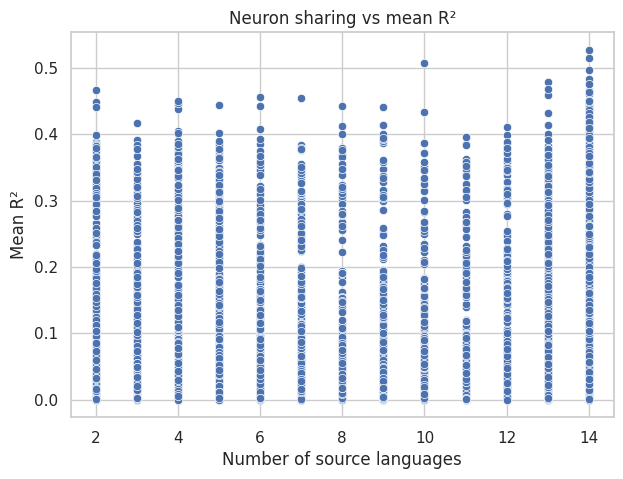

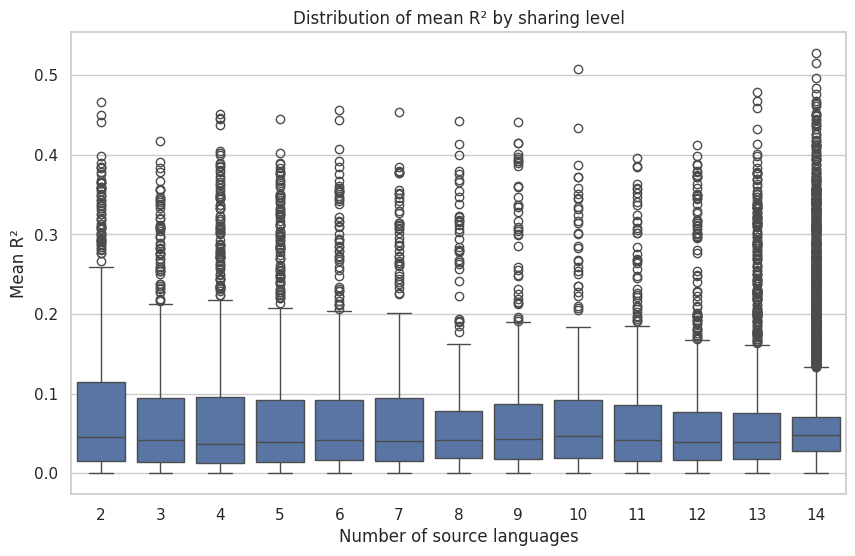

Top language combinations by proportion of high-R² (≥ 0.6) neurons:


,source_languages,total,high,mean_high_r2,max_high_r2,proportion_high
0,"bn,hi,ja,ur",21,11.0,0.705665,0.705665,0.523810
1,"bn,fr,hi,pt,ur",21,11.0,0.603427,0.603427,0.523810
2,"en,es,fr,hi,it,ko,pt,ru,tr,ur,zh",21,11.0,0.606190,0.606190,0.523810
3,"bn,es,fr,it,ja,pt,ru,ur",21,11.0,0.659579,0.659579,0.523810
4,"fr,ko,ru,tr",21,7.0,0.623179,0.623179,0.333333
5,"de,fr,hi,pt,ru",21,7.0,0.664015,0.664015,0.333333
6,"bn,hi,ko,ru",21,7.0,0.723470,0.723470,0.333333
7,"de,ja,ko,ru,zh",21,7.0,0.668397,0.668397,0.333333
8,"bn,fr,hi",21,7.0,0.654434,0.654435,0.333333
9,"bn,es,fr,hi,ja,ko,ru,zh",21,7.0,0.666647,0.666647,0.333333


/tmp/ipykernel_1330463/3004055008.py:108: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=combo_stats.head(15), y="source_languages", x="proportion_high", palette="mako")


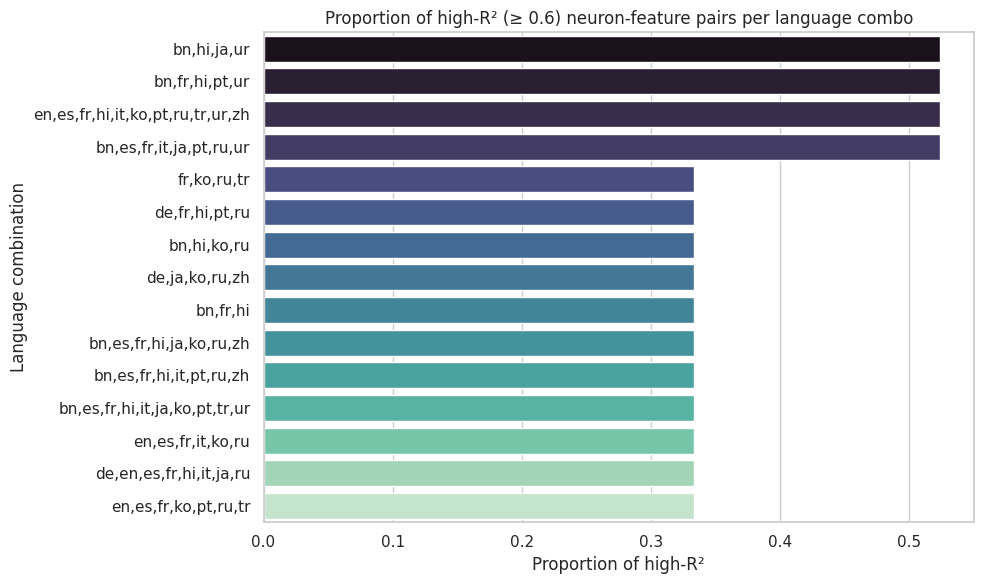

Per-language high R² analysis (threshold = 0.6):


,language,total_pairs,high_pairs,proportion_high
0,fr,296583,2796,0.009427
1,es,297360,2754,0.009262
2,it,284928,2473,0.008679
3,pt,280266,2361,0.008424
4,hi,246057,1985,0.008067
5,de,254478,2006,0.007883
6,en,262647,2029,0.007725
7,ru,252273,1938,0.007682
8,bn,227367,1713,0.007534
9,ja,240828,1798,0.007466


/tmp/ipykernel_1330463/3004055008.py:152: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=lang_stats, x="language", y="proportion_high", palette="crest")


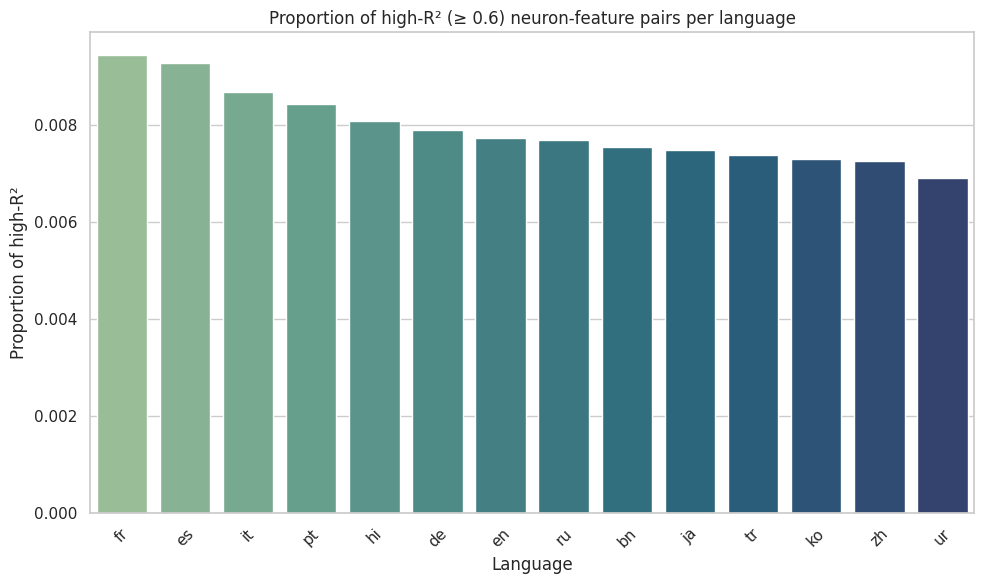

/tmp/ipykernel_1330463/3004055008.py:162: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=lang_stats.sort_values("high_pairs", ascending=False),


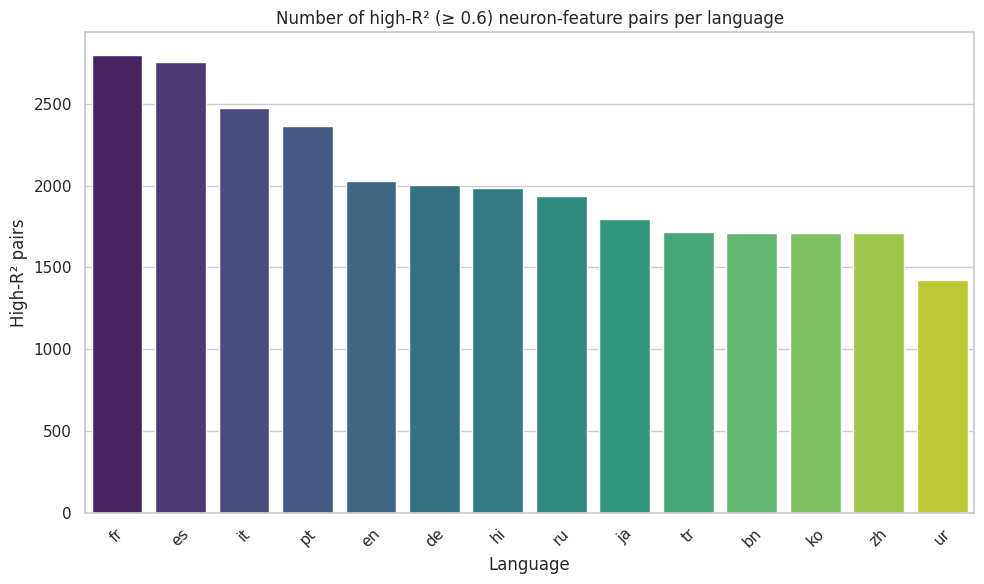

In [27]:
analyse(1, "inventory_phoible_ra")